## 导入必要的包

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 用来正常显示中文标签
plt.rcParams['font.sans-serif'] = ['SimHei']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

## 任务1
用Pandas读取studentScore.xlsx，查看前三行和后两行，将缺失值丢弃处理导出为新文件studentScoreP.xlsx。

In [10]:
# 读取文件
df = pd.read_excel('studentScore.xlsx')
print("前三行数据：")
print(df.head(3))
print("后两行数据：")
print(df.tail(2))
df_cleaned = df.dropna()
df_cleaned.to_excel('studentScoreP.xlsx', index=False)

前三行数据：
      考号   姓名  班级     语文     数学   英语   总分  班名次
0  70605   张璐  一班  131.0  143.0  144  418    1
1  70603   王雪  二班  131.0  135.0  144  410    2
2  70609  李林霖  一班  127.0  139.0  142  408    3
后两行数据：
       考号   姓名  班级    语文    数学  英语   总分  班名次
66  70664  周禹志  二班  75.0  23.0  34  132   31
67  70665  李鸿涛  二班  66.0  23.0  34  123   32


## 任务2
选择预处理后的studentScoreP.xlsx文件中的列姓名、考号、班级、语文、数学、英语，导出为新的excel文件studentScoreP_new.xlsx；

In [14]:
df = pd.read_excel('studentScoreP.xlsx')
df = df[['姓名', '考号', '班级', '语文', '数学', '英语']]
df.to_excel('studentScoreP_new.xlsx', index=False)

## 任务3
重新读取新的数据集studentScoreP_new.xlsx，并选择语文、数学、英语大于等于100分的所有数据集，导出为新的文本文件studentScoreP_newGood.xlsx

In [19]:
df = pd.read_excel('studentScoreP_new.xlsx')
# condition = (df['语文'] >= 100)
# df[condition]
df[(df['语文'] >= 100) & (df['数学'] >= 100) & (df['英语'] >= 100)]
df.to_excel('studentScoreP_newGood.xlsx')

## 任务4
重新读取studentScoresP_new.xlsx，按照列班级分类汇总各班语文、数学、英语的平均成绩，并将分组计算结果导出到文本文件studentScoresP_MeanGroup.xlsx中，要求分组名不作为列名。

In [21]:
df = pd.read_excel('studentScoreP_new.xlsx')
grouped_mean = df.groupby('班级')[['语文', '数学', '英语']].mean()
grouped_mean.to_excel('studentScoreP_MeanGroup.xlsx', index=False)

## 任务5
重新读取studentScoresP_new.xlsx，计算每位同学语文、数学、英语的平均成绩，结果保留两位小数，并将平均成绩作为一个新的列“均值”添加到原始文件，并按照列均值降序排列，并将排序后的结果转存到studentScoresP_Mean.xlsx中。

In [ ]:
df = pd.read_excel('studentScoreP_new.xlsx')

## 任务6
读取新的数据集studentScoresP_Mean.xlsx，根据一班的均值做箱线图。图标题设置为“一班平均成绩箱线图”，标签设置为"一班"。

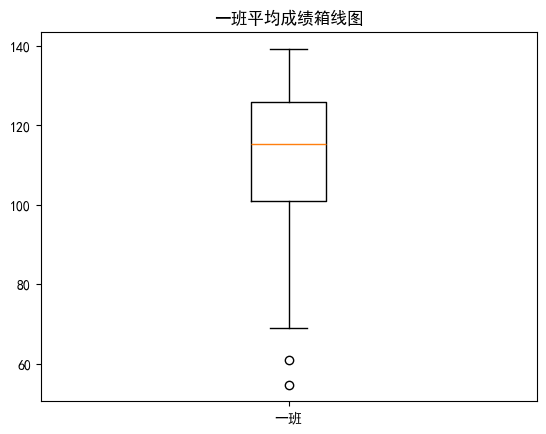

In [26]:
df = pd.read_excel('studentScoreP_Mean.xlsx')
mean_scores = df[df['班级'] == '一班']['均值']
plt.boxplot(mean_scores, tick_labels=['一班'])
plt.title('一班平均成绩箱线图')
plt.show()

## 任务7
根据均值列进行统计，统计优[120-150]、良[90-120)、中[60-90)、差[30-60) 的人数，绘制饼状图。要求显示优良中差标签，显示百分占比，保留两位小数。

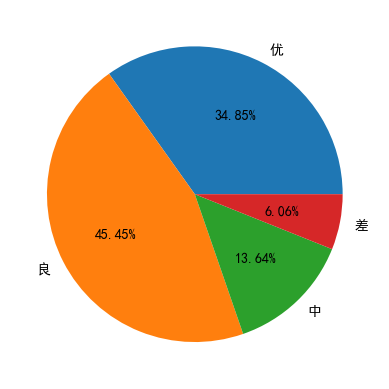

In [25]:
df = pd.read_excel('studentScoreP_Mean.xlsx')
a = df[df['均值'] >= 120]['均值'].count()
b = df[(df['均值'] >= 90) & (df['均值'] < 120)]['均值'].count()
c = df[(df['均值'] >= 60) & (df['均值'] < 90)]['均值'].count()
d = df[df['均值'] < 60]['均值'].count()
counts = [a, b, c, d]
plt.pie(counts, labels=['优', '良', '中', '差'], autopct='%0.2f%%')
plt.show()